In [1]:
import numpy as np
import zarr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [2]:
# POD storage locations
ZARR_DISP = "displacements.zarr"

DISP_POD_GROUP      = "pod_full"
DISP_POD_U_NAME     = "U"
DISP_POD_MEAN_NAME  = "mean"
DISP_POD_SVALS_NAME = "svals"

In [3]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE

import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,
    H: int, W: int,
    bottom_elem_idx: np.ndarray,
):
    flat = vec_elem[bottom_elem_idx]
    return flat.reshape(H, W)



import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)
      elem_node_ids_bot : (Ne_bot,4)
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]

    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot

In [4]:
def load_displacement_pod_basis(
    zarr_path=ZARR_DISP,
    pod_group=DISP_POD_GROUP,
    U_name=DISP_POD_U_NAME,
    mean_name=DISP_POD_MEAN_NAME,
    svals_name=DISP_POD_SVALS_NAME,
):
    """
    Load displacement POD basis info from zarr.

    Returns
    -------
    U : ndarray
        POD basis matrix
    mean_u : ndarray
        Mean displacement vector
    svals : ndarray
        Singular values
    """
    root = zarr.open(zarr_path, mode="r")
    grp = root[pod_group]

    U = np.asarray(grp[U_name])
    mean_u = np.asarray(grp[mean_name]).squeeze()
    svals = np.asarray(grp[svals_name]).squeeze()

    return U, mean_u, svals

In [5]:
def cumulative_explained_variance_from_svals(svals):
    """
    POD explained variance ratio uses sigma_i^2.
    """
    energy = svals**2
    ratio = energy / np.sum(energy)
    cum_ratio = np.cumsum(ratio)
    return ratio, cum_ratio

In [6]:
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 600,
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.0,
        "lines.markersize": 5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

In [7]:
set_publication_style()

In [112]:
def plot_pod_cumulative_explained_variance(
    zarr_path=ZARR_DISP,
    pod_group=DISP_POD_GROUP,
    svals_name=DISP_POD_SVALS_NAME,
    highlight_r=None,
    figsize=(5.8, 4.2),
    save_path=None,
    dpi=600,
):
    root = zarr.open(zarr_path, mode="r")
    svals = np.asarray(root[pod_group][svals_name]).squeeze()

    ratio, cum_ratio = cumulative_explained_variance_from_svals(svals)
    modes = np.arange(1, len(svals) + 1)

    # print per-mode and cumulative captured energy
    print("Mode | Individual energy (%) | Cumulative energy (%)")
    print("-" * 50)
    for m, r, c in zip(modes, ratio, cum_ratio):
        print(f"{m:4d} | {100*r:21.6f} | {100*c:21.6f}")

    if highlight_r is not None and 1 <= highlight_r <= len(svals):
        print()
        print(
            f"First {highlight_r} modes capture "
            f"{100*cum_ratio[highlight_r - 1]:.6f}% of the energy."
        )

    # prepend the origin so the first segment is drawn from (0,0)
    modes_plot = np.concatenate(([0], modes))
    cum_ratio_plot = np.concatenate(([0.0], cum_ratio))

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(modes_plot, cum_ratio_plot, marker="o", lw=4.4, ms=10)

    if highlight_r is not None and 1 <= highlight_r <= len(svals):
        y = cum_ratio[highlight_r - 1]
        ax.axvline(highlight_r, linestyle="--", linewidth=2.4)
        ax.axhline(y, linestyle="--", linewidth=2.4)
        ax.plot(highlight_r, y, "o", ms=7)

    ax.set_xlabel("Number of POD modes retained")
    ax.set_ylabel("Cumulative explained variance")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    ax.set_xlim(0, len(svals))
    ax.set_ylim(0.0, 1.01)
    ax.grid(True, alpha=0.25, linewidth=1.4)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, ax

Mode | Individual energy (%) | Cumulative energy (%)
--------------------------------------------------
   1 |             94.919121 |             94.919121
   2 |              3.748100 |             98.667221
   3 |              0.908059 |             99.575280
   4 |              0.268519 |             99.843799
   5 |              0.055592 |             99.899391
   6 |              0.039282 |             99.938673
   7 |              0.022652 |             99.961325
   8 |              0.017554 |             99.978879
   9 |              0.012688 |             99.991567
  10 |              0.008433 |            100.000000


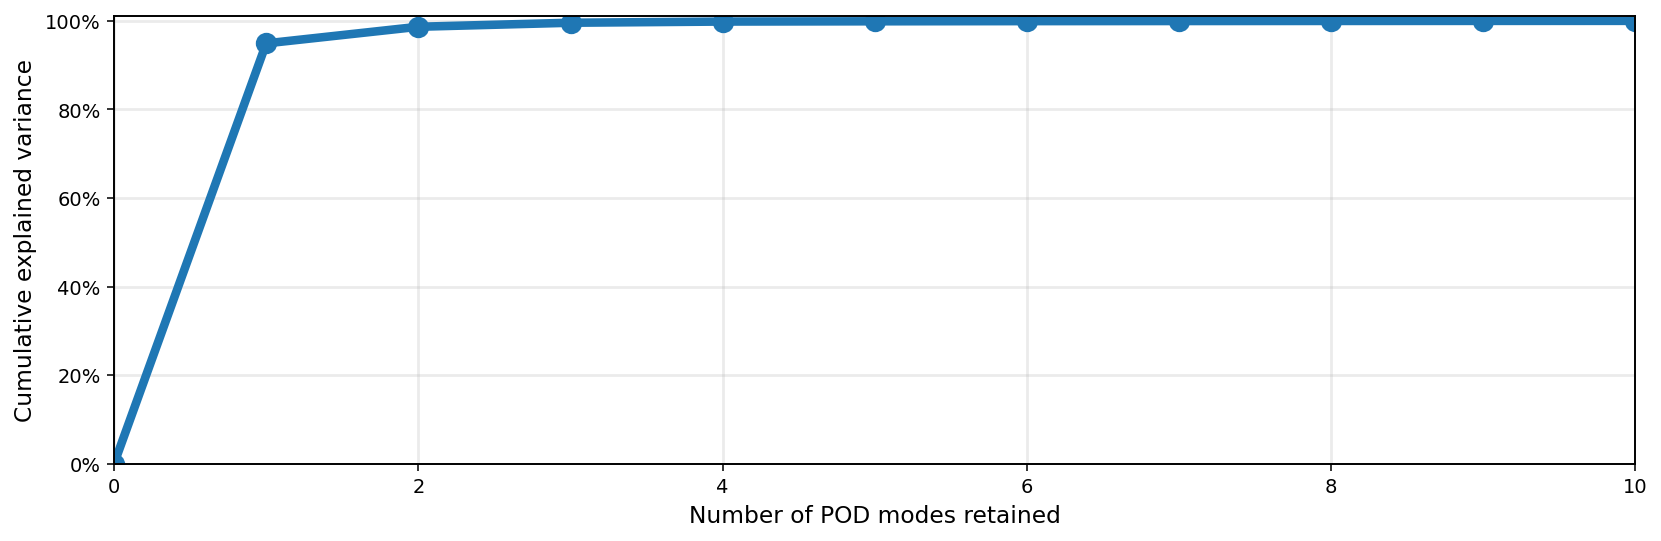

In [113]:
fig, ax = plot_pod_cumulative_explained_variance(
    zarr_path="displacements.zarr",
    highlight_r=None,
    save_path="disp_pod_cumulative_explained_variance.png",
    dpi=500,
    figsize=(12,4)
)
plt.show()

In [13]:
def displacement_vector_to_nodal(mode_vec, n_nodes, dof_order="interleaved"):
    """
    Convert flat displacement vector to (n_nodes, 3).

    dof_order:
      - 'interleaved': [ux1, uy1, uz1, ux2, uy2, uz2, ...]
      - 'blocked':     [ux_all, uy_all, uz_all]
    """
    mode_vec = np.asarray(mode_vec).squeeze()

    if mode_vec.size != 3 * n_nodes:
        raise ValueError(
            f"Expected mode vector of length {3*n_nodes}, got {mode_vec.size}"
        )

    if dof_order == "interleaved":
        return mode_vec.reshape(n_nodes, 3)
    elif dof_order == "blocked":
        ux = mode_vec[:n_nodes]
        uy = mode_vec[n_nodes:2*n_nodes]
        uz = mode_vec[2*n_nodes:]
        return np.column_stack([ux, uy, uz])
    else:
        raise ValueError("dof_order must be 'interleaved' or 'blocked'")

In [14]:
def set_axes_equal_3d(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.5 * np.max(maxs - mins)

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

In [15]:
def clean_3d_axes(ax):
    ax.grid(False)

    try:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
    except Exception:
        pass

    try:
        ax.xaxis.line.set_linewidth(0.8)
        ax.yaxis.line.set_linewidth(0.8)
        ax.zaxis.line.set_linewidth(0.8)
    except Exception:
        pass

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")

In [16]:
import numpy as np

def load_bottom_surface_mesh_direct(nodes_csv: str, elems_csv: str):
    """
    Robust bottom-surface mesh loader:

    - elems_csv contains both layers; bottom layer is second half of rows
    - bottom nodes are defined as the unique node IDs referenced by bottom elements
      (this is the only assumption that cannot be broken by file ordering)

    Returns:
      node_xyz_bot : (Nbot, 3)
      elem_conn_bot: (Ne_bot, 4) 0-based indices into node_xyz_bot
      node_ids_bot : (Nbot,)     node IDs corresponding to node_xyz_bot rows
      elem_node_ids_bot : (Ne_bot,4) original node IDs for debugging
    """
    nodes = np.loadtxt(nodes_csv, delimiter=",")
    elems = np.loadtxt(elems_csv, delimiter=",")

    node_ids = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)

    elem_ids = elems[:, 0].astype(np.int64)
    elem_node_ids = elems[:, 1:5].astype(np.int64)
    Ne = elem_node_ids.shape[0]
    if Ne % 2 != 0:
        raise ValueError(f"Expected even number of elements (2 layers), got Ne={Ne}")

    # bottom layer = second half of element rows
    half = Ne // 2
    elem_node_ids_bot = elem_node_ids[half:, :]   # (Ne_bot, 4)

    # bottom node IDs = unique node IDs referenced by bottom elements
    bottom_node_ids = np.unique(elem_node_ids_bot.reshape(-1))

    # pull those nodes from nodes_csv
    # (use a dict for fast lookup by ID)
    id2xyz = {int(nid): node_xyz[i] for i, nid in enumerate(node_ids)}

    missing = [int(nid) for nid in bottom_node_ids if int(nid) not in id2xyz]
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} node IDs referenced by bottom elements are missing from nodes_csv. "
            f"Example missing IDs: {missing[:10]}"
        )

    # build bottom node table, sorted by node_id
    node_ids_bot = np.sort(bottom_node_ids.astype(np.int64))
    node_xyz_bot = np.vstack([id2xyz[int(nid)] for nid in node_ids_bot]).astype(np.float64)

    # map node_id -> local index [0..Nbot-1]
    id2bot = {int(nid): i for i, nid in enumerate(node_ids_bot)}

    # remap element connectivity to local indices
    get_idx = np.vectorize(lambda nid: id2bot.get(int(nid), -1), otypes=[np.int64])
    elem_conn_bot = get_idx(elem_node_ids_bot)

    bad = np.where(elem_conn_bot < 0)
    if bad[0].size > 0:
        ei = int(bad[0][0])
        raise ValueError(
            "Internal mapping failure (shouldn't happen if missing-check passed).\n"
            f"Example bad elem row: {ei}\n"
            f"elem_node_ids_bot[ei] = {elem_node_ids_bot[ei]}\n"
            f"elem_conn_bot[ei]     = {elem_conn_bot[ei]}"
        )

    print("[bottom surface mesh — robust]")
    print("  node_xyz_bot:", node_xyz_bot.shape)
    print("  elem_conn_bot:", elem_conn_bot.shape)
    print("  node_id range:", int(node_ids_bot.min()), int(node_ids_bot.max()))
    print("  conn min/max:", int(elem_conn_bot.min()), int(elem_conn_bot.max()))

    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot


In [24]:
def load_vis_bottom_surface_mesh(
    nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
    elems_csv="GOH_Elements_Test_for_Visualization.csv",
):
    """
    Uses your robust bottom-surface loader.
    Returns bottom-surface node coordinates and quad connectivity.
    """
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_bottom_surface_mesh_direct(
        nodes_csv=nodes_csv,
        elems_csv=elems_csv,
    )
    return node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot

In [25]:
def displacement_vector_to_nodal(mode_vec, n_nodes, dof_order="interleaved"):
    """
    Convert flat displacement vector to (n_nodes, 3).

    dof_order:
      - 'interleaved': [ux1, uy1, uz1, ux2, uy2, uz2, ...]
      - 'blocked':     [ux_all, uy_all, uz_all]
    """
    mode_vec = np.asarray(mode_vec).squeeze()

    if mode_vec.size != 3 * n_nodes:
        raise ValueError(f"Expected length {3*n_nodes}, got {mode_vec.size}")

    if dof_order == "interleaved":
        return mode_vec.reshape(n_nodes, 3)
    elif dof_order == "blocked":
        ux = mode_vec[:n_nodes]
        uy = mode_vec[n_nodes:2*n_nodes]
        uz = mode_vec[2*n_nodes:]
        return np.column_stack([ux, uy, uz])
    else:
        raise ValueError("dof_order must be 'interleaved' or 'blocked'")

In [62]:
def plot_displacement_pod_mode_2d_signed(
    mode_idx,
    nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
    elems_csv="GOH_Elements_Test_for_Visualization.csv",
    zarr_path=ZARR_DISP,
    pod_group=DISP_POD_GROUP,
    U_name=DISP_POD_U_NAME,
    dof_order="interleaved",
    component="uz",           # "ux", "uy", "uz", or "magnitude"
    triangulate_quads=True,
    cmap="coolwarm",
    figsize=(6.0, 5.0),
    title=None,
    show_colorbar=True,
    save_path=None,
    dpi=600,
):
    """
    Plot a POD mode on the bottom surface in the x-y plane.

    For signed components (ux, uy, uz), the color limits are forced to be
    symmetric about zero for cleaner interpretation.
    """

    # -------------------------
    # Load POD basis
    # -------------------------
    root = zarr.open(zarr_path, mode="r")
    U = np.asarray(root[pod_group][U_name])

    # -------------------------
    # Load bottom-surface mesh
    # -------------------------
    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_vis_bottom_surface_mesh(
        nodes_csv=nodes_csv,
        elems_csv=elems_csv,
    )

    n_bot = node_xyz_bot.shape[0]

    # -------------------------
    # Match POD basis orientation
    # -------------------------
    if U.shape[0] == 3 * n_bot:
        U_use = U
    elif U.shape[1] == 3 * n_bot:
        U_use = U.T
    else:
        raise ValueError(
            f"Could not match POD basis shape {U.shape} to bottom-surface node count {n_bot}. "
            f"Expected one dimension to equal 3*n_bot = {3*n_bot}."
        )

    if not (0 <= mode_idx < U_use.shape[1]):
        raise IndexError(f"mode_idx={mode_idx} out of range for basis with {U_use.shape[1]} modes")

    # -------------------------
    # Extract and reshape mode
    # -------------------------
    mode_vec = U_use[:, mode_idx]
    mode_xyz = displacement_vector_to_nodal(mode_vec, n_bot, dof_order=dof_order)

    x = node_xyz_bot[:, 0]
    y = node_xyz_bot[:, 1]

    # -------------------------
    # Select plotted field
    # -------------------------
    if component == "ux":
        field = mode_xyz[:, 0]
        cbar_label = r"$\phi_i^{(x)}$"
        signed = True
    elif component == "uy":
        field = mode_xyz[:, 1]
        cbar_label = r"$\phi_i^{(y)}$"
        signed = True
    elif component == "uz":
        field = mode_xyz[:, 2]
        cbar_label = r"$\phi_i^{(z)}$"
        signed = True
    elif component == "magnitude":
        field = np.linalg.norm(mode_xyz, axis=1)
        cbar_label = r"$\|\phi_i\|$"
        signed = False
    else:
        raise ValueError("component must be 'ux', 'uy', 'uz', or 'magnitude'")

    # -------------------------
    # Convert quads to triangles
    # -------------------------
    if triangulate_quads:
        tri1 = elem_conn_bot[:, [0, 1, 2]]
        tri2 = elem_conn_bot[:, [0, 2, 3]]
        triangles = np.vstack([tri1, tri2])
    else:
        raise ValueError("tripcolor needs triangles; keep triangulate_quads=True")

    # -------------------------
    # Color limits
    # -------------------------
    if signed:
        vmax = np.max(np.abs(field))
        vmin = -vmax
    else:
        vmin = np.min(field)
        vmax = np.max(field)

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)

    tpc = ax.tripcolor(
        x, y, triangles, field,
        shading="gouraud",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title is None:
        title = f"POD mode {mode_idx + 1} ({component})"
    ax.set_title(title)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if show_colorbar:
        cbar = fig.colorbar(tpc, ax=ax)
        cbar.set_label(cbar_label)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, ax

[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720


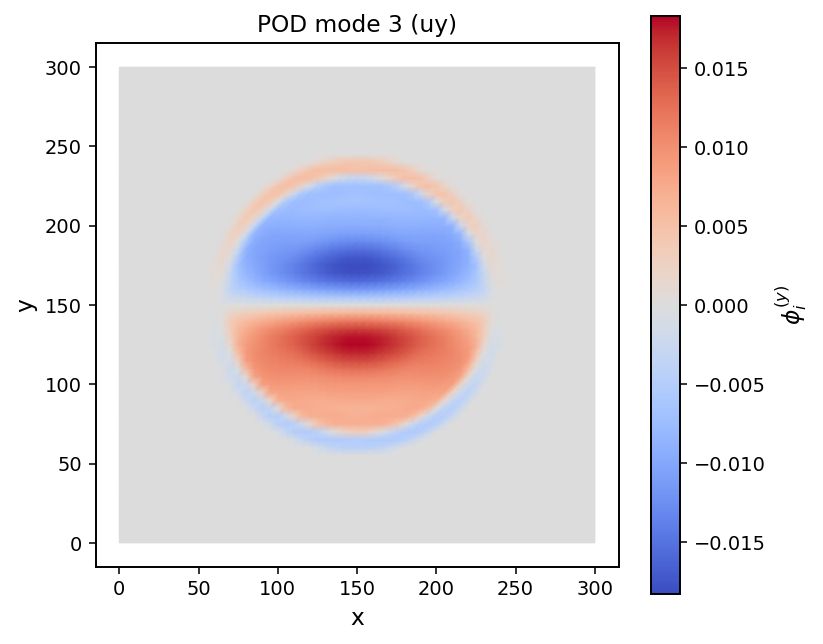

In [96]:
fig, ax = plot_displacement_pod_mode_2d_signed(
    mode_idx=2,
    nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
    elems_csv="GOH_Elements_Test_for_Visualization.csv",
    zarr_path="displacements.zarr",
    dof_order="blocked",
    component="uy",
    cmap="coolwarm",
    save_path="disp_mode_3_uy.png",
    dpi=500,
)
plt.show()

In [ ]:
def plot_displacement_pod_mode_2d_with_mesh(
    mode_idx,
    nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
    elems_csv="GOH_Elements_Test_for_Visualization.csv",
    zarr_path=ZARR_DISP,
    pod_group=DISP_POD_GROUP,
    U_name=DISP_POD_U_NAME,
    dof_order="interleaved",
    component="magnitude",
    cmap="viridis",
    figsize=(6.0, 5.0),
    mesh_color="k",
    mesh_linewidth=0.2,
    mesh_alpha=0.18,
    title=None,
    show_colorbar=True,
    save_path=None,
    dpi=600,
):
    root = zarr.open(zarr_path, mode="r")
    U = np.asarray(root[pod_group][U_name])

    node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_vis_bottom_surface_mesh(
        nodes_csv=nodes_csv,
        elems_csv=elems_csv,
    )

    n_bot = node_xyz_bot.shape[0]

    if U.shape[0] == 3 * n_bot:
        U_use = U
    elif U.shape[1] == 3 * n_bot:
        U_use = U.T
    else:
        raise ValueError(
            f"Could not match POD basis shape {U.shape} to bottom-surface node count {n_bot}. "
            f"Expected one dimension to equal 3*n_bot = {3*n_bot}."
        )

    mode_vec = U_use[:, mode_idx]
    mode_xyz = displacement_vector_to_nodal(mode_vec, n_bot, dof_order=dof_order)

    x = node_xyz_bot[:, 0]
    y = node_xyz_bot[:, 1]

    if component == "ux":
        field = mode_xyz[:, 0]
        cbar_label = r"$\phi_i^{(x)}$"
    elif component == "uy":
        field = mode_xyz[:, 1]
        cbar_label = r"$\phi_i^{(y)}$"
    elif component == "uz":
        field = mode_xyz[:, 2]
        cbar_label = r"$\phi_i^{(z)}$"
    elif component == "magnitude":
        field = np.linalg.norm(mode_xyz, axis=1)
        cbar_label = r"$\|\phi_i\|$"
    else:
        raise ValueError("component must be 'ux', 'uy', 'uz', or 'magnitude'")

    tri1 = elem_conn_bot[:, [0, 1, 2]]
    tri2 = elem_conn_bot[:, [0, 2, 3]]
    triangles = np.vstack([tri1, tri2])

    fig, ax = plt.subplots(figsize=figsize)

    tpc = ax.tripcolor(
        x, y, triangles, field,
        shading="gouraud",
        cmap=cmap,
    )

    ax.triplot(
        x, y, triangles,
        color=mesh_color,
        linewidth=mesh_linewidth,
        alpha=mesh_alpha,
    )

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title is None:
        title = f"POD mode {mode_idx + 1} ({component})"
    ax.set_title(title)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if show_colorbar:
        cbar = fig.colorbar(tpc, ax=ax)
        cbar.set_label(cbar_label)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, ax

In [20]:
U, mean_u, svals = load_displacement_pod_basis("displacements.zarr")
print("U shape     :", U.shape)
print("mean shape  :", mean_u.shape)
print("svals shape :", svals.shape)

node_xyz_bot, elem_conn_bot, node_ids_bot, elem_node_ids_bot = load_vis_bottom_surface_mesh(
    "GOH_Nodes_Test_for_Visualization.csv",
    "GOH_Elements_Test_for_Visualization.csv",
)
print("bottom nodes:", node_xyz_bot.shape)
print("bottom elems:", elem_conn_bot.shape)
print("3 * Nbot    :", 3 * node_xyz_bot.shape[0])

U shape     : (11163, 10)
mean shape  : (11163,)
svals shape : (10,)
[bottom surface mesh — robust]
  node_xyz_bot: (3721, 3)
  elem_conn_bot: (3600, 4)
  node_id range: 3722 7442
  conn min/max: 0 3720
bottom nodes: (3721, 3)
bottom elems: (3600, 4)
3 * Nbot    : 11163
